# WP3 Hazard Prioritization Notebook
This notebook computes multi-hazard prioritisation scores for African countries and regions using the WP3 dataset. It loads indicators extracted from multiple sources, applies a consistent normalisation (rank percentiles), combines indicators into dimension scores, and aggregates to hazard scores and regional scores.

The methodology follows the project requirements:- **Equal weighting** across indicators and dimensions (though the code is modular to test other weightings).- **Rank normalization** is used for all indicators; this approach is simple and robust to outliers【150559529294701†L127-L130】.- **Event-based totals are scaled using the World Bank's mid-year population estimates**, which are based on a **de facto** definition of population【845294053508267†L66-L71】.

You can modify parameters such as whether hazard-agnostic indicators are included and the threshold for overlapping constructs. Coverage diagnostics and sensitivity analyses are presented throughout the notebook.


## Methodology summary

This analysis considers five dimensions—**Prevalence**, **Scale**, **Impact**, **Cascade impacts**, and **Future relevance**—for each hazard. Each dimension is populated using all available indicators across multiple data sources (EM‑DAT, DesInventar, IDMC, INFORM Risk, INFORM Climate Change, WorldRiskIndex, ThinkHazard). Indicators are normalised to a common 0–1 scale using percentile ranks across countries. High values always correspond to worse outcomes.

To avoid double counting when multiple sources measure the same construct (e.g., deaths per capita in EM‑DAT and DesInventar), we implement a modular *overlap arbitration* rule. When a construct shows significant overlap between sources (≥25% of cases, configurable), only the most complete source is used. This avoids over-weighting correlated variables【519522339192286†L68-L70】.

Hazard‑agnostic indicators such as **Lack of coping capacity** or **Adaptive capacities** are replicated across hazards to fill gaps in dimensions like Cascade and Future relevance. Sensitivity runs are provided to see the effect of including or excluding these proxies.


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

# Parameters (users can modify these)
include_hazard_agnostic = False  # Include hazard-agnostic indicators (e.g., WRI.A, Lack Coping)
overlap_threshold = 0.25         # Fraction of overlapping cases required to trigger arbitration per construct

# File paths (update if necessary)
data_path = 'C:\\pipelines\\sewa-multihazar\\data\\intermediate\\wp3_country_indicators_long.csv'
pop_zip_path = 'C:\\pipelines\\sewa-multihazar\\data\\raw\\population\\API_SP.POP.TOTL_DS2_en_csv_v2_34.zip'

In [14]:

# Load the main indicators long-format file
ind_df = pd.read_csv(data_path)

# Harmonise dimension and region names
dim_map = {
    'Cascade impacts': 'Cascade',
    'Future relevance': 'Future',
    'Impact': 'Impact',
    'Prevalence': 'Prevalence',
    'Scale': 'Scale'
}
ind_df['dimension'] = ind_df['dimension'].map(dim_map).fillna(ind_df['dimension'])

# Clean region names
ind_df['region'] = ind_df['region'].str.replace('Southern Africaincl. ', 'Southern Africa ').str.replace('\(incl. ', '(')

# Define hazard list (exclude 'All Hazards')
hazards = [h for h in sorted(ind_df['hazard'].unique()) if h != 'All Hazards']

# Load WDI population (mid-year)
import zipfile
with zipfile.ZipFile(pop_zip_path) as zf:
    with zf.open('API_SP.POP.TOTL_DS2_en_csv_v2_34.csv') as f:
        pop_df_raw = pd.read_csv(f, skiprows=4)

# Keep only 2024 column and rename
pop_df = pop_df_raw[['Country Code', '2024']].rename(columns={'Country Code': 'iso3', '2024': 'pop_2024'})
# Some DataBank countries may not be in WDI (e.g., Réunion). Provide fallback from file if needed.

# Merge population onto indicator dataset
ind_df = ind_df.merge(pop_df, on='iso3', how='left')
print('Loaded indicators:', ind_df.shape)
print('Countries with missing population:', ind_df[ind_df['pop_2024'].isna()]['iso3'].unique())



Loaded indicators: (4038, 14)
Countries with missing population: ['REU']


In [15]:

# Mapping for ThinkHazard levels: values are already numeric (1–4). Convert to 0–1 by scaling.
def map_th_level(value):
    try:
        return (float(value) - 1.0) / 3.0 if pd.notnull(value) else np.nan
    except Exception:
        return np.nan

# Define indicator metadata: direction and construct grouping
# All metrics are treated as 'higher is worse' (direction = 1). If a metric is beneficial, set direction = -1.
# Construct grouping helps with overlap arbitration and scoring decisions.
indicator_meta = {}

# Prevalence: events per year and ThinkHazard levels
for src in ['EM-DAT (selected)', 'DesInventar (selected)']:
    indicator_meta[f'{src}.EVENTS_PER_YEAR_2000_2024'] = {'dimension': 'Prevalence', 'construct': 'events', 'direction': 1}
# ThinkHazard levels for each hazard
for th in ['TH.DG_LEVEL','TH.FL_LEVEL','TH.CF_LEVEL','TH.CY_LEVEL','TH.EH_LEVEL','TH.TS_LEVEL','TH.UF_LEVEL','TH.WF_LEVEL']:
    indicator_meta[th] = {'dimension': 'Prevalence', 'construct': 'hazard_level', 'direction': 1}

# Scale indicators
scale_ids = [
    'EM-DAT.MAGNITUDE_MEAN_2000_2024','DESINVENTAR.MAGNITUDE_MEAN_2000_2024',
    'EM-DAT.DURATION_MEAN_DAYS_2000_2024','DESINVENTAR.DURATION_MEAN_DAYS_2000_2024',
    'EM-DAT.ADMIN_SPREAD_MEAN_ADM2_2000_2024','DESINVENTAR.ADMIN_SPREAD_MEAN_ADM2_2000_2024',
    'WRI.E','WRI.EI_03','WRI.EI_04','WRI.EI_05','WRI.EI_06',
    'INFORM.DIM.HAZARD_EXPOSURE','INFORM.HAZEX.COASTAL_FLOOD','INFORM.HAZEX.DROUGHT','INFORM.HAZEX.RIVER_FLOOD','INFORM.HAZEX.TROPICAL_CYCLONE'
]
for sid in scale_ids:
    indicator_meta[sid] = {'dimension': 'Scale', 'construct': 'exposure', 'direction': 1}

# Impact indicators (per capita); drop totals by default in scoring
impact_per_ids = [
    'EM-DAT.DEATHS_PER100K_2000_2024','DESINVENTAR.DEATHS_PER100K_2000_2024',
    'EM-DAT.AFFECTED_PER100K_2000_2024','DESINVENTAR.AFFECTED_PER100K_2000_2024',
    'EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024','DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024'
]
for sid in impact_per_ids:
    indicator_meta[sid] = {'dimension': 'Impact', 'construct': sid.split('.')[1].split('_')[0].lower(), 'direction': 1}

# Additional Impact indicators (housing destruction) used for QA only by default
qa_impact_ids = [
    'DESINVENTAR.AFFECTED_SUM_2000_2024','DESINVENTAR.DEATHS_SUM_2000_2024','DESINVENTAR.DESTROYED_HOUSES_SUM_2000_2024',
    'DESINVENTAR.AFFECTED_HOUSES_SUM_2000_2024','EM-DAT.DAMAGE_ADJ_USD_SUM_2000_2024','DESINVENTAR.LOSS_USD_SUM_2000_2024'
]
for sid in qa_impact_ids:
    indicator_meta[sid] = {'dimension': 'Impact', 'construct': 'qa', 'direction': 1}

# Cascade indicators
indicator_meta['IDMC.DISPLACEMENTS_PER100K_2000_2024_POPREF'] = {'dimension': 'Cascade', 'construct': 'displacement', 'direction': 1}
indicator_meta['INFORM.DIM.LACK_COPING'] = {'dimension': 'Cascade', 'construct': 'lack_coping', 'direction': 1}
# IDMC sum and DESINVENTAR evacuation/relocation considered QA only
for sid in ['IDMC.DISPLACEMENTS_SUM','DESINVENTAR.EVACUATED_SUM_2000_2024','DESINVENTAR.RELOCATED_SUM_2000_2024']:
    indicator_meta[sid] = {'dimension': 'Cascade', 'construct': 'qa', 'direction': 1}

# Future indicators
future_ids_specific = [
    'INFORMCC.CHG_HAZEX.DROUGHT.2050.pessimistic',
    'INFORMCC.CHG_HAZEX.FLOOD.2050.pessimistic',
    'INFORMCC.CHG_HAZEX.COASTAL_FLOOD.2050.pessimistic'
]
for sid in future_ids_specific:
    indicator_meta[sid] = {'dimension': 'Future', 'construct': 'hazard_change', 'direction': 1}
# Hazard-agnostic future proxies
indicator_meta['WRI.A'] = {'dimension': 'Future', 'construct': 'adaptive_capacity', 'direction': 1}
indicator_meta['INFORMCC.RISK_INDEX.2050.pessimistic'] = {'dimension': 'Future', 'construct': 'risk_index', 'direction': 1}

# Function to get construct for indicator

def get_construct(ind_id):
    return indicator_meta.get(ind_id, {}).get('construct', 'other')

def get_dimension(ind_id):
    return indicator_meta.get(ind_id, {}).get('dimension')

def get_direction(ind_id):
    return indicator_meta.get(ind_id, {}).get('direction', 1)

# Utility: percentile rank (0–1) with higher values worse

def rank_normalize(series):
    ser = series.copy().astype(float)
    # handle missing values separately
    valid = ser.dropna()
    ranks = valid.rank(method='min') - 1  # ranks start at 0
    n = len(valid)
    normed = ranks / (n - 1) if n > 1 else pd.Series([0]*len(valid), index=valid.index)
    # Map back to full series
    result = pd.Series(index=series.index, dtype=float)
    result[valid.index] = normed
    result[ser.isna()] = np.nan
    return result


In [16]:

# Filter to indicators that are defined in indicator_meta
ind_df['construct'] = ind_df['indicator_id'].apply(get_construct)
ind_df['dim_clean'] = ind_df['indicator_id'].apply(get_dimension)
ind_df['direction'] = ind_df['indicator_id'].apply(get_direction)

# Identify hazard-agnostic rows
agnostic_df = ind_df[ind_df['hazard'] == 'All Hazards'].copy()
other_df = ind_df[ind_df['hazard'] != 'All Hazards'].copy()

# Replicate hazard-agnostic indicators to each hazard if include_hazard_agnostic is True
if include_hazard_agnostic:
    replicated_rows = []
    for idx, row in agnostic_df.iterrows():
        for hz in hazards:
            # Only replicate if the dimension matches the indicator_meta (dim_clean not None)
            rep = row.copy()
            rep['hazard'] = hz
            replicated_rows.append(rep)
    rep_df = pd.DataFrame(replicated_rows)
else:
    rep_df = pd.DataFrame(columns=ind_df.columns)

# Combine back
combined = pd.concat([other_df, rep_df], ignore_index=True)

# Remove QA-only indicators from scoring set (keep them for diagnostics)
qa_indicators = [k for k,v in indicator_meta.items() if v['construct']=='qa']
scoring_df = combined[~combined['indicator_id'].isin(qa_indicators)].copy()

# Overlap arbitration for selected constructs (deaths, affected, events, damage)
overlap_constructs = {
    'deaths': ['EM-DAT.DEATHS_PER100K_2000_2024','DESINVENTAR.DEATHS_PER100K_2000_2024'],
    'affected': ['EM-DAT.AFFECTED_PER100K_2000_2024','DESINVENTAR.AFFECTED_PER100K_2000_2024'],
    'events': ['EM-DAT.EVENTS_PER_YEAR_2000_2024','DESINVENTAR.EVENTS_PER_YEAR_2000_2024'],
    'damage': ['EM-DAT.DAMAGE_ADJ_USD_PER_CAPITA_2000_2024','DESINVENTAR.LOSS_USD_PER_CAPITA_2000_2024']
}

# Function to apply arbitration per construct
def apply_overlap_arbitration(df):
    df = df.copy()
    drop_indices = []
    for constr, inds in overlap_constructs.items():
        # Check overlap per hazard
        # Determine iso3-hazard pairs where both sources have non-null values
        pivot = df[df['indicator_id'].isin(inds)].pivot_table(index=['iso3','hazard'], columns='indicator_id', values='value_raw', aggfunc='first')
        # Count overlaps (rows with both indicators non-null)
        overlap_mask = pivot.dropna(subset=inds).index
        # Determine fraction across all iso3-hazard pairs for this construct
        total_pairs = pivot.shape[0]
        frac_overlap = len(overlap_mask) / total_pairs if total_pairs > 0 else 0
        if frac_overlap >= overlap_threshold:
            # Determine completeness by counting non-null per indicator across df
            completeness = df[df['indicator_id'].isin(inds)].groupby('indicator_id')['value_raw'].count()
            # Keep indicator with highest completeness
            best_indicator = completeness.idxmax()
            # Drop the other indicator from df
            for ind in inds:
                if ind != best_indicator:
                    drop_indices.extend(df[df['indicator_id']==ind].index.tolist())
    return df.drop(drop_indices)

scoring_df = apply_overlap_arbitration(scoring_df)

print('After replication and arbitration:', scoring_df.shape)


After replication and arbitration: (2877, 17)


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_27472\2013171294.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([other_df, rep_df], ignore_index=True)


In [17]:

# Compute normalised scores per indicator (percentile ranking)
scoring_df['value_numeric'] = pd.to_numeric(scoring_df['value_raw'], errors='coerce')
scoring_df['norm'] = scoring_df.groupby('indicator_id')['value_numeric'].transform(rank_normalize)

# If direction is -1 (beneficial), invert the normalised scores
scoring_df['norm_adj'] = scoring_df['norm'] * scoring_df['direction']

# Dimension-level aggregation: equal weights across indicators (mean)
dim_scores = scoring_df.groupby(['iso3','hazard','dim_clean'])['norm_adj'].mean().reset_index().rename(columns={'norm_adj':'dimension_score'})
# Compute number of indicators used per dimension for coverage
ind_counts = scoring_df.groupby(['iso3','hazard','dim_clean']).size().reset_index(name='n_indicators')
dim_scores = dim_scores.merge(ind_counts, on=['iso3','hazard','dim_clean'], how='left')

# Hazard-level scores: equal weight across dimensions (renormalise if missing)
# Dimensions to include
all_dims = ['Prevalence','Scale','Impact','Cascade','Future']

# Pivot dimension scores to wide format
wide_dim = dim_scores.pivot_table(index=['iso3','hazard'], columns='dim_clean', values='dimension_score')
# Compute mean across available dimensions
hazard_scores = wide_dim.mean(axis=1).reset_index().rename(columns={0:'hazard_score'})
# Also compute coverage ratio (dimensions available / 5)
hazard_scores['dimension_coverage_ratio'] = wide_dim.count(axis=1).values / len(all_dims)

# Merge population and region back for later aggregation
hazard_scores = hazard_scores.merge(ind_df[['iso3','region','pop_2024']].drop_duplicates(), on='iso3', how='left')

# Country ranking per hazard within the country? Actually we rank hazards by hazard_score per country but that may not be needed here.


In [18]:

# Compute regional scores using population-weighted and unweighted methods
# For population-weighted: sum(pop * hazard_score)/sum(pop)
reg_scores_pw = hazard_scores.groupby(['region','hazard']).apply(lambda x: np.average(x['hazard_score'], weights=x['pop_2024'])).reset_index(name='region_hazard_score_popw')
# Unweighted: simple mean
reg_scores_unw = hazard_scores.groupby(['region','hazard'])['hazard_score'].mean().reset_index(name='region_hazard_score_unw')

# Merge both
reg_scores = reg_scores_pw.merge(reg_scores_unw, on=['region','hazard'], how='left')

# Compute rankings within each region (population-weighted)
reg_scores['rank_popw'] = reg_scores.groupby('region')['region_hazard_score_popw'].rank(method='min', ascending=False)
reg_scores['rank_unw'] = reg_scores.groupby('region')['region_hazard_score_unw'].rank(method='min', ascending=False)

print('Regional scores sample:')
print(reg_scores.head())


Regional scores sample:
           region                                 hazard  \
0  Central Africa                                Drought   
1  Central Africa                                   Dust   
2  Central Africa                         Flash Flooding   
3  Central Africa                               Heatwave   
4  Central Africa  Riverine Flooding Continued & Cluster   

   region_hazard_score_popw region_hazard_score_unw  rank_popw  rank_unw  
0                  0.459138                0.316544        2.0       5.0  
1                  0.249665                0.204724        7.0       7.0  
2                  0.378751                0.336018        5.0       3.0  
3                  0.454542                0.312821        3.0       6.0  
4                  0.580672                0.469451        1.0       1.0  


C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_27472\334969430.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reg_scores_pw = hazard_scores.groupby(['region','hazard']).apply(lambda x: np.average(x['hazard_score'], weights=x['pop_2024'])).reset_index(name='region_hazard_score_popw')


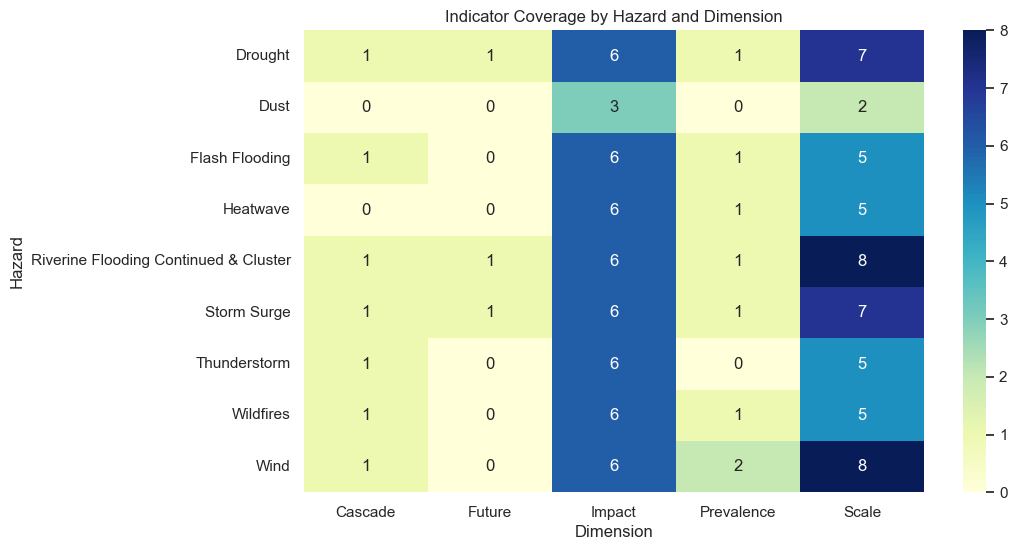

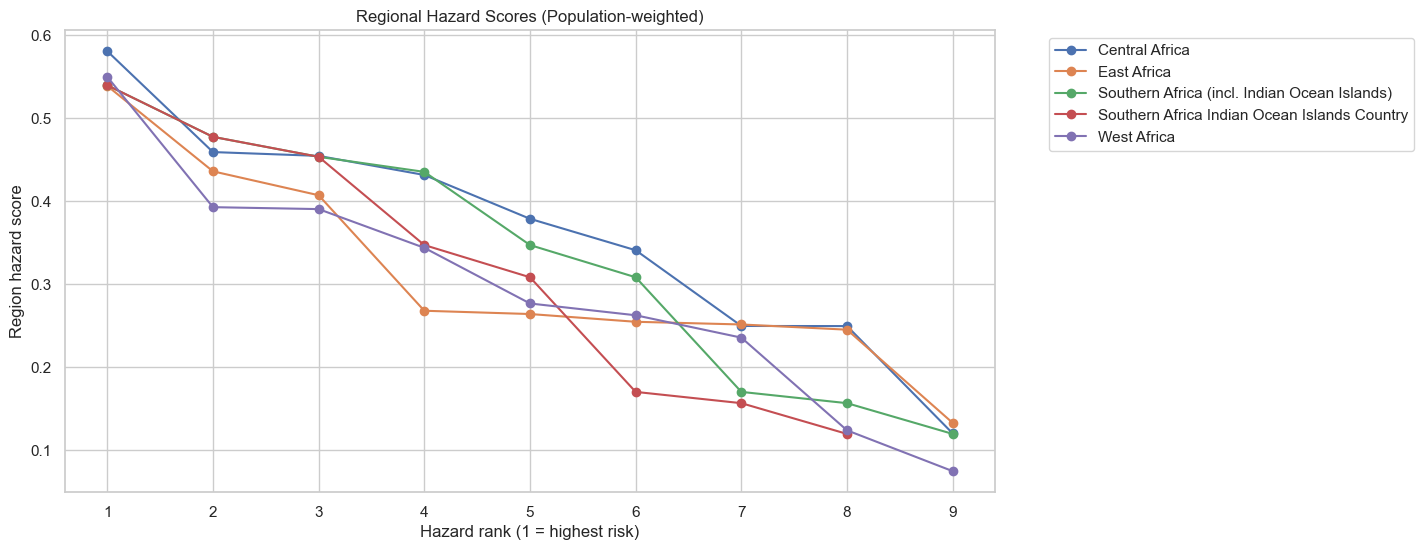

In [19]:

# Coverage heatmap: number of indicators by hazard and dimension
coverage_matrix = scoring_df.groupby(['hazard','dim_clean'])['indicator_id'].nunique().unstack(fill_value=0)
plt.figure(figsize=(10,6))
sns.heatmap(coverage_matrix, annot=True, cmap='YlGnBu')
plt.title('Indicator Coverage by Hazard and Dimension')
plt.ylabel('Hazard')
plt.xlabel('Dimension')
plt.show()

# Regional hazard rankings (population-weighted)
plt.figure(figsize=(12,6))
for region_name, sub in reg_scores.groupby('region'):
    plt.plot(sub.sort_values('rank_popw')['rank_popw'], sub.sort_values('rank_popw')['region_hazard_score_popw'], marker='o', label=region_name)
plt.title('Regional Hazard Scores (Population-weighted)')
plt.xlabel('Hazard rank (1 = highest risk)')
plt.ylabel('Region hazard score')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


In [20]:

# Top 3 hazards per country (population-weighted ranking within region is not used here)
country_top_hazards = hazard_scores.copy()
country_top_hazards['rank_in_country'] = country_top_hazards.groupby('iso3')['hazard_score'].rank(method='min', ascending=False)
top3 = country_top_hazards[country_top_hazards['rank_in_country'] <= 3].sort_values(['iso3','rank_in_country'])
print('Top 3 hazards per country:')
print(top3[['iso3','hazard','hazard_score','rank_in_country']].head(30))

# Top 3 hazards per region (population-weighted)
top_reg = reg_scores[reg_scores['rank_popw'] <= 3].sort_values(['region','rank_popw'])
print('Top 3 hazards per region (population-weighted):')
print(top_reg[['region','hazard','region_hazard_score_popw','rank_popw']].head(30))


Top 3 hazards per country:
   iso3                                 hazard hazard_score  rank_in_country
10  AGO                           Thunderstorm     0.634731              1.0
11  AGO                           Thunderstorm     0.634731              1.0
6   AGO  Riverine Flooding Continued & Cluster     0.554512              3.0
7   AGO  Riverine Flooding Continued & Cluster     0.554512              3.0
22  BDI                           Thunderstorm     0.498773              1.0
20  BDI  Riverine Flooding Continued & Cluster     0.488967              2.0
18  BDI                         Flash Flooding     0.448303              3.0
29  BEN  Riverine Flooding Continued & Cluster     0.677278              1.0
28  BEN                               Heatwave     0.487179              2.0
25  BEN                                Drought     0.432032              3.0
37  BFA                               Heatwave     0.487179              1.0
38  BFA  Riverine Flooding Continued & Cluster   

In [21]:
# Top 3 hazards per region (population-weighted)
top_reg = reg_scores[reg_scores['rank_popw'] <= 3].sort_values(['region','rank_popw'])
print('Top 3 hazards per region (population-weighted):')
print(top_reg[['region','hazard','region_hazard_score_popw','rank_popw']].head(30))

Top 3 hazards per region (population-weighted):
                                          region  \
4                                 Central Africa   
0                                 Central Africa   
3                                 Central Africa   
13                                   East Africa   
11                                   East Africa   
9                                    East Africa   
24  Southern Africa (incl. Indian Ocean Islands)   
18  Southern Africa (incl. Indian Ocean Islands)   
22  Southern Africa (incl. Indian Ocean Islands)   
33  Southern Africa Indian Ocean Islands Country   
27  Southern Africa Indian Ocean Islands Country   
31  Southern Africa Indian Ocean Islands Country   
40                                   West Africa   
36                                   West Africa   
41                                   West Africa   

                                   hazard  region_hazard_score_popw  rank_popw  
4   Riverine Flooding Continued & Clus

## Interpretation and next steps

The tables and charts above provide a starting point for multi‑hazard prioritisation:

- **Dimension scores**: represent the average percentile‑rank severity across all available indicators in that dimension. Coverage ratios indicate how many indicators were available for each country–hazard combination.
- **Hazard scores**: are simple averages of dimension scores (equal weights). Missing dimensions are renormalised out. The notebook can be extended to support custom dimension weights.
- **Regional aggregation**: uses 2024 mid‑year population as weights【845294053508267†L66-L71】 to produce population‑weighted scores. Unweighted means are also shown to explore the influence of population size.

You can experiment by changing the `include_hazard_agnostic` flag or `overlap_threshold` parameter at the top of the notebook and re‑running the cells to see how the rankings respond.

Caveats to keep in mind:
- Some hazards have sparse coverage in certain dimensions, especially Future relevance and Cascade. When the dimension coverage ratio is low, hazard scores should be interpreted cautiously.
- Equal weighting across indicators can amplify constructs represented by multiple correlated indicators【519522339192286†L68-L70】. The overlap arbitration rule mitigates this for major constructs (deaths, affected, events, damage).
- Rank normalisation emphasises relative positions rather than absolute differences; the country at rank 1 may not have dramatically worse outcomes than rank 2.

Use the outputs of this notebook as inputs for expert discussions and to guide further analysis.
